In [6]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### Detecting and removing outliers using IQR method and analyzing the correlation between mileage and price

In [ ]:
# Statistic Metrics
mean_price = df['sellingprice'].mean()
median_price = df['sellingprice'].median()
mode_price = df['sellingprice'].mode()
std_price = df['sellingprice'].std()
skewness = df['sellingprice'].skew()

"""Interpretation of skewness:
Low skewness: |As| < 0.5
Moderate skewness: 1 <= |As| <= 0.5
High skewness: |As| > 1
Left-skewed: Median < Arithmetic Mean < Mode (Data concentration)
Right-skewed: Median > Arithmetic Mean > Mode (Data concentration)
"""
# IQR (Interquartile Range)
"""Detecting outliers. A value is considered an outlier if it lies below Q1 - IQR * 1.5
or above Q3 + IQR * 1.5"""

q1 = df['sellingprice'].quantile(0.25)
q3 = df['sellingprice'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Mean price: {mean_price:.0f}\nMedian price: {median_price:.0f}\nMode price: {mode_price[0]:.0f}\nStandard deviation: {std_price:.0f}\nSkewness: {skewness:.2f}\nQ1: {q1:.0f}\nQ3: {q3:.0f}\n")

# Outlier detection using IQR method to ensure model robustness against extreme market anomalies
outliers = df[(df['sellingprice'] < lower_bound) | (df['sellingprice'] > upper_bound)]
clean_df = df[(df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

print(f"Detected outliers count: {len(outliers)}")
print(f"Average before: {df['sellingprice'].mean():.2f}")
print(f"Average after: {clean_df['sellingprice'].mean():.2f}")

# Drop out outliers
limit = df['sellingprice'].quantile(0.95)
clean_ford = df[df['sellingprice'] < limit]
print(f"Average without top 5%: {clean_ford['sellingprice'].mean():.2f}")

# Nice way to calculate nulls
missing_cond = df.groupby('make')['condition'].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)
print(f"\nNulls percentage in condition feature\n {missing_cond.head(10)}")
print("\nChecking correlation between car's mileage and its price")
print(f"Cars manufactured before 2000: {df[df['year'] <= 2000][['sellingprice', 'year', 'odometer', 'condition']].corr().iloc[2,0]}")
print(f"Cars manufactured after 2000: {df[df['year'] > 2000][['sellingprice', 'year', 'odometer', 'condition']].corr().iloc[2,0]}")

Mean price: 13611
Median price: 12100
Mode price: 11000
Standard deviation: 9750
Skewness: 1.95
Q1: 6900
Q3: 18200

Detected outliers count: 16354
Average before: 13611.36
Average after: 12644.22
Average without top 5%: 12198.25

Nulls percentage in condition feature
 make
Daewoo        33.333333
Plymouth      17.142857
Oldsmobile     8.585859
Isuzu          7.843137
Saturn         6.476593
Saab           6.404959
Pontiac        5.729967
Mercury        5.107004
Suzuki         4.436229
Volvo          4.118268
Name: condition, dtype: float64

Checking correlation between car's mileage and its price
Cars manufactured before 2000: -0.23935032735817247
Cars manufactured after 2000: -0.568740358553554


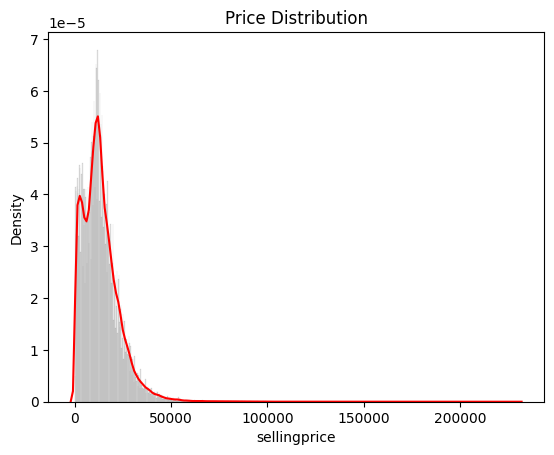

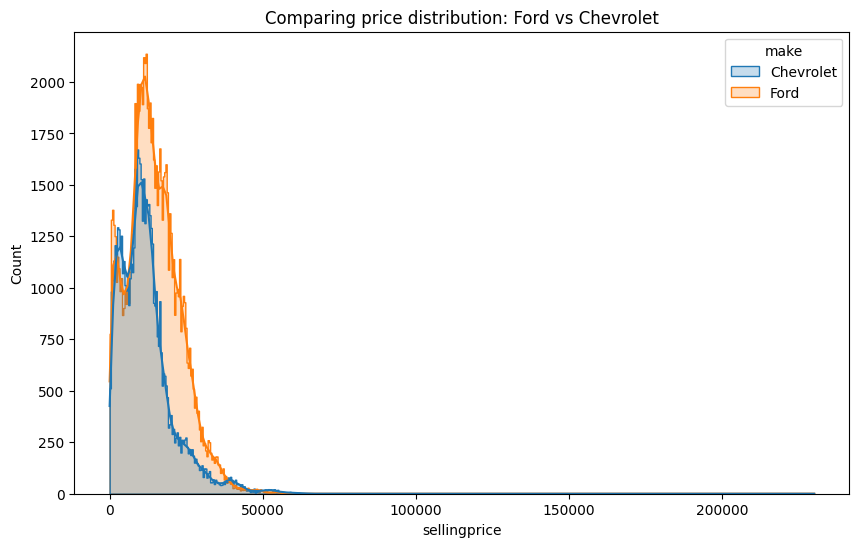

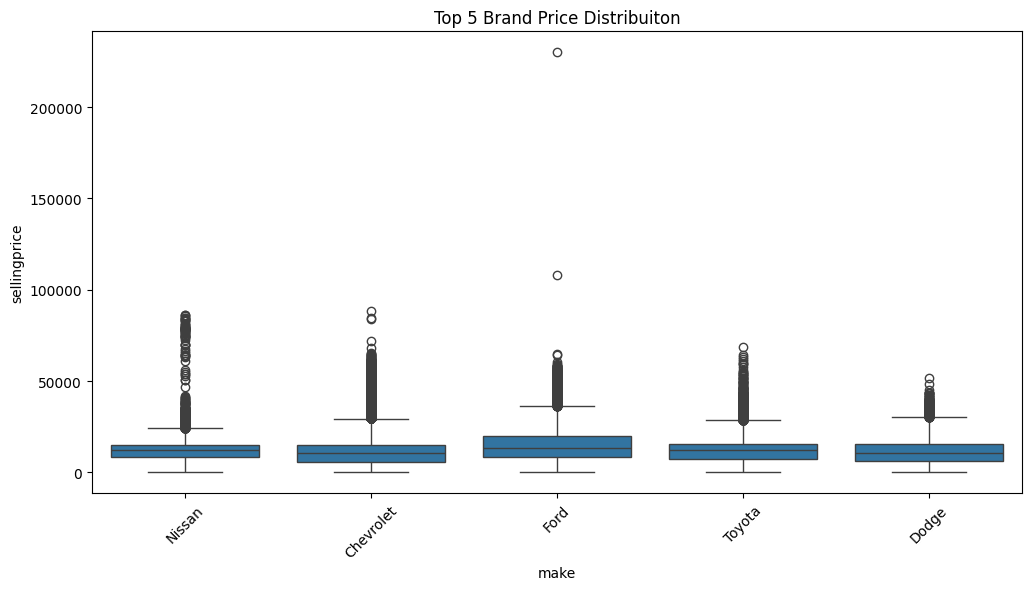

sellingprice    1.000000
odometer       -0.582397
condition       0.321944
year            0.586484
Name: sellingprice, dtype: float64


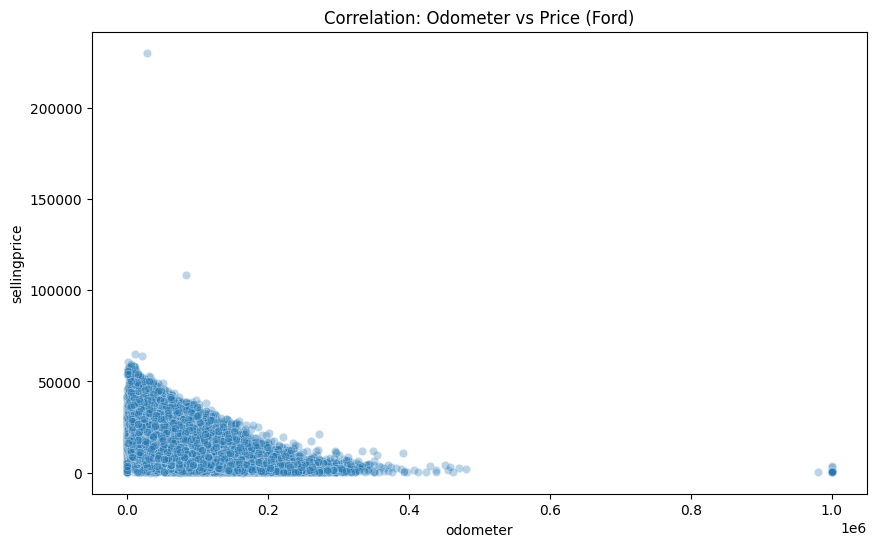

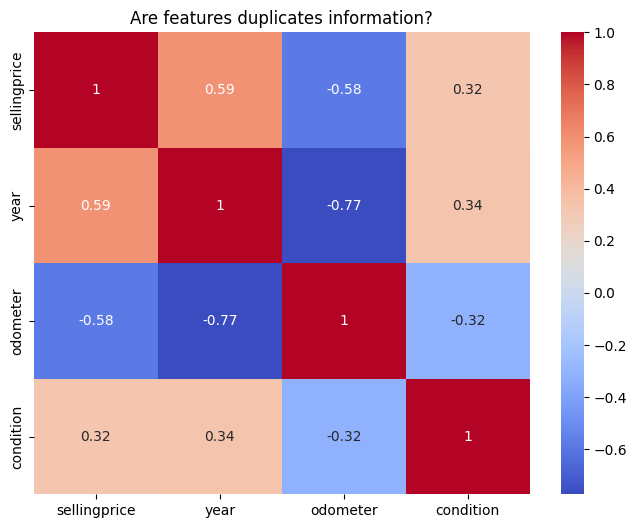

In [33]:
# Histogram with KDE with different color and other charts
sns.histplot(df['sellingprice'], kde=False, color='gray', stat='density', alpha=0.2)
sns.kdeplot(df['sellingprice'], color='red')
plt.title("Price Distribution")
plt.show()
 
brands = df[df['make'].isin(['Ford', 'Chevrolet'])]
plt.figure(figsize=(10,6))
sns.histplot(brands, x='sellingprice', hue='make', kde=True, element='step')
plt.title("Comparing price distribution: Ford vs Chevrolet")
plt.show()

top_brands = df['make'].value_counts().nlargest(5).index
subset = df[df['make'].isin(top_brands)]

plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x='make', y='sellingprice')
plt.title("Top 5 Brand Price Distribuiton")
plt.xticks(rotation=45)
plt.show()

correlation = df[['sellingprice', 'odometer', 'condition', 'year']].corr()
print(correlation['sellingprice'])

ford_df = df[df['make'] == 'Ford']

plt.figure(figsize=(10,6))
sns.scatterplot(data=ford_df, x='odometer', y='sellingprice', alpha=0.3)
plt.title("Correlation: Odometer vs Price (Ford)")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['sellingprice', 'year', 'odometer', 'condition']].corr(), annot=True, cmap='coolwarm')
plt.title("Are features duplicates information?")
plt.show()